# Network Attack Detection using Isolation Forest

This notebook demonstrates how anomaly detection models can identify
suspicious network traffic patterns using the CIC-IDS2017 dataset.

Workflow:
1. Load and clean network traffic data
2. Train an Isolation Forest anomaly detection model
3. Score network flows for anomalous behavior
4. Visualize suspicious traffic patterns

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

## 2. Data Cleaning

In [5]:
df = pd.read_csv("data/raw.csv", low_memory=False)
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 3. Feature Preparation

In [6]:
df["Attack"] = (df["Label"] != "BENIGN").astype(int)

df["Attack"].value_counts()

Attack
0    440031
1    252672
Name: count, dtype: int64

In [7]:
X = df.drop(columns=["Label", "Attack"])
X = X.select_dtypes(include="number")
X = X.replace([np.inf, -np.inf], np.nan)

y = df["Attack"]

print(X.shape)

(692703, 78)


## 4. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(554162, 78)
(138541, 78)


## 5. Model Training

### Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm.  
Instead of learning attack labels, it isolates unusual observations in the dataset.

Network flows that require fewer splits to isolate in the tree structure  
are considered more anomalous.

In [9]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


## 6. Model Interpretation

## Model Output Interpretation

The anomaly detection model assigns scores to each network flow.
Lower scores indicate flows that deviate more strongly from normal traffic behavior.

## Security Interpretation

The lowest anomaly scores represent network flows that deviate most
from the baseline learned from benign traffic.

In an operational security environment these flows would not
automatically be classified as attacks. Instead they would be
prioritized for analyst review and correlated with other signals
such as firewall logs, endpoint activity, or SIEM alerts.

Anomaly detection helps surface unusual traffic patterns that may
indicate scanning activity, denial-of-service traffic, or other
suspicious behavior.

## 7. Visualization

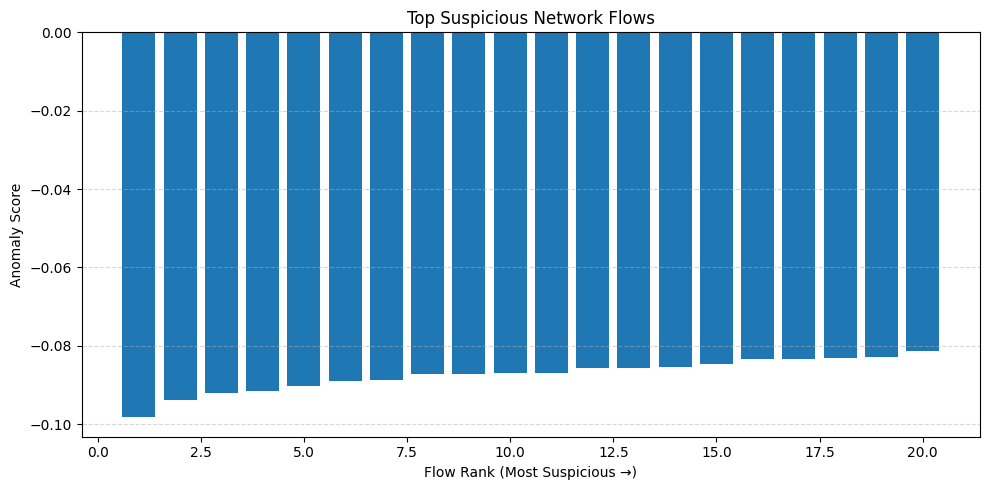

In [10]:
# Visualize the most suspicious network flows

import pandas as pd
import matplotlib.pyplot as plt

df_scores = pd.read_csv("outputs/top_anomalies.csv").sort_values("anomaly_score")

df_scores = df_scores.head(20)

plt.figure(figsize=(10,5))
plt.bar(range(1, len(df_scores)+1), df_scores["anomaly_score"])

plt.title("Top Suspicious Network Flows")
plt.xlabel("Flow Rank (Most Suspicious →)")
plt.ylabel("Anomaly Score")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

The visualization highlights the network flows with the lowest anomaly scores
identified by the model. These flows deviate most strongly from the baseline
behavior learned from benign traffic and may correspond to scanning activity,
slow HTTP attacks, or denial-of-service patterns present in the dataset.

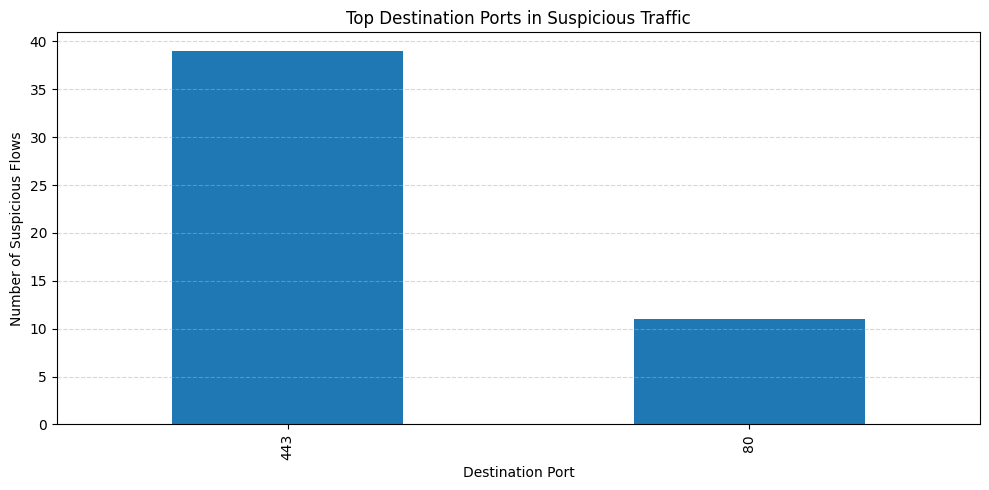

In [11]:
# Analyze destination ports for the most suspicious flows

import pandas as pd
import matplotlib.pyplot as plt

# Load the suspicious flows
df_anomalies = pd.read_csv("outputs/top_anomalies.csv")

# Count destination ports
top_ports = df_anomalies["Destination Port"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_ports.plot(kind="bar")

plt.title("Top Destination Ports in Suspicious Traffic")
plt.xlabel("Destination Port")
plt.ylabel("Number of Suspicious Flows")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Suspicious Port Analysis

Analyzing destination ports in anomalous network flows helps identify
the services potentially targeted by attacks.

Web ports such as 80 and 443 often appear in denial-of-service attacks
or slow HTTP attacks (slowloris / slowhttptest) present in the CIC-IDS2017 dataset.

This analysis helps security analysts quickly understand which network
services may require investigation.